# T022 · 基于配体的筛选：神经网络

Developed in the CADD seminar 2020, Volkamer Lab, Charité/FU Berlin 

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域的技能，并为研究项目提供流程模板作为起点。

作者：

- Ahmed Atta, CADD Seminar 2020, Charité/FU Berlin
- Sakshi Misra, 实习 (2020/21), [Volkamer lab](https://volkamerlab.org), Charité
- Talia B. Kimber, 2020/21, [Volkamer lab](https://volkamerlab.org), Charité
- Andrea Volkamer, 2021, [Volkamer lab](https://volkamerlab.org), Charité

## 本教程的目标

近年来，机器学习和深度学习在药物研究中的应用在解决药物发现中的各种问题方面展现了令人鼓舞的成果。在本教程中，我们将熟悉神经网络的基础知识。我们将学习如何构建一个简单的两层神经网络，并在 ChEMBL 数据的子集上训练它，以预测化合物针对 EGFR（目标激酶）的 pIC50 值。此外，我们将从一个外部未标注数据集中选出预测活性最高的三个化合物。

### *理论* 部分的内容

- 生物学背景
    - EGFR 激酶
    - 化合物活性度量
    - 分子编码
- 神经网络
    - 什么是神经网络？
    - 激活函数
    - 损失函数
- 训练神经网络
- Keras 工作流程
- 神经网络的优势与应用

### *实践* 部分的内容

- 数据准备
- 定义神经网络
- 训练模型
- 评估与在测试集上的预测
    - 散点图
- 在外部/未标注数据上的预测
    - 选出前 3 个化合物

### 参考文献

 - 理论背景：
     - 论文    
         - Siddharth Sharma, "Activation functions in neural networks". [_International Journal of Engineering Applied Sciences and Technology, 2020_ **Vol. 4, Issue 12,** 310-316 (2020).](https://www.ijeast.com/papers/310-316,Tesma412,IJEAST.pdf)
         - Shun-ichi Amari, "Backpropagation and stochastic gradient descent method", [*ScienceDirect  **Volume 5, Issue 4-5**, 185-196*](https://doi.org/10.1016/0925-2312(93)90006-O)
         - Gisbert Schneider et al., "Artificial neural networks for computer-based molecular design", [*ScienceDirect **Volume 70, Issue 3**, 175-222*](https://doi.org/10.1016/S0079-6107(98)00026-1)
         - Filippo Amato et al., "Artificial neural networks in medical diagnosis", [*ScienceDirect  **Volume 11, Issue 2**, 47-58*](https://doi.org/10.2478/v10136-012-0031-x)         
         
     - 博客文章
          - Imad Dabbura, *Coding Neural Network — Forward Propagation and Backpropagtion*, [medium, accessed March 25th, 2026](https://medium.com/data-science/coding-neural-network-forward-propagation-and-backpropagtion-ccf8cf369f76).
          - Lavanya Shukla, *Designing Your Neural Networks*, [towardsdatascience, accessed Sep 23rd, 2019](https://towardsdatascience.com/designing-your-neural-networks-a5e4617027ed)
          - Arthur Arnx, *First neural network for beginners explained (with code)*, [towardsdatascience, accessed Jan 13th, 2019](https://towardsdatascience.com/first-neural-network-for-beginners-explained-with-code-4cfd37e06eaf) 
          - Varun Divakar, *Understanding Backpropagation*, [QuantInst, accessed Nov 19th, 2018](https://blog.quantinsti.com/backpropagation/) 
               
- 软件包：
     - [rdkit](http://rdkit.org/): Greg Landrum, *RDKit Documentation*, [PDF](https://www.rdkit.org/UGM/2012/Landrum_RDKit_UGM.Fingerprints.Final.pptx.pdf), Release on 2019.09.1.
     - [Keras](https://keras.io/): 书籍章节："An Introduction to Deep Learning and Keras" in [*Learn Keras for Deep Neural Networks* (2019), **page(s):1-16**](https://doi.org/10.1007/978-1-4842-4240-7).
     - keras 中的 [Sequential model](https://keras.io/api/models/sequential/)
     - [Model training APIs](https://keras.io/api/models/model_training_apis/#model-training-apis)

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 22
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

### 生物学背景

#### EGFR 激酶

- [表皮生长因子受体 (EGFR)](https://en.wikipedia.org/wiki/Epidermal_growth_factor_receptor) 是存在于细胞膜上的一种跨膜蛋白/受体。它是 ErbB 受体家族的一员。
- EGFR 在控制正常细胞生长、凋亡和其他细胞功能方面发挥重要作用。
- 它通过配体与其胞外域结合而被激活，激活后 EGFR 从无活性的单体形式转变为有活性的同源二聚体。
- EGFR 受体在多种类型的肿瘤或癌症中上调，因此 EGFR 抑制是一种可能阻止癌细胞生长的生物疗法。

#### 化合物活性度量

- **IC50** 是药物的半数最大抑制浓度，表示需要多少药物才能将生物过程抑制一半。
- **pIC50** 是 IC50 值的负对数。它比 IC50 值更容易解读，是衡量化合物效力的常用指标（更多细节请参见 **教程 T001**）。

#### 分子编码

对于机器学习算法，分子需要转换成机器可读的格式，例如特征列表。在本 notebook 中，使用分子指纹。

分子指纹将化学结构和分子特征编码为一个位串，其中每个位置 "1" 表示存在某个特征，"0" 表示不存在某个特征。常用的指纹之一是 **M**olecular **ACC**ess **S**ystem 指纹 [(MACCS Keys)](https://docs.eyesopen.com/toolkits/python/graphsimtk/fingerprint.html#maccs)，它是 166 位的结构键描述符，其中每个位与一个 [SMARTS](https://docs.eyesopen.com/toolkits/python/oechemtk/glossary.html#term-smarts) 模式相关联，编码特定的子结构（更多细节请参见 **教程 T004**）。

### 神经网络

#### 什么是神经网络？

神经网络，也称为人工神经网络 (ANN)，是机器学习算法的一个子集。神经网络的结构和名称灵感来源于人脑，模拟了生物神经元相互传递信号的方式。

![基本结构](./images/basic_structure.png)

*图 1：* 该图展示了人工神经网络的基本结构。取自博客文章："*Designing Your Neural Networks*", Lavanya Shukla, [towardsdatascience](https://towardsdatascience.com/designing-your-neural-networks-a5e4617027ed).

如上图所示，ANN 由三个主要层组成：_输入层_、若干 _隐藏层_ 和 _输出层_。让我们更深入地了解每一层。

1. **输入神经元或输入层**
   - 该层表示用于进行预测的特征数量。
   - 输入向量需要每个特征一个输入神经元。
2. **隐藏层及每层的神经元数量**
    - 隐藏层的维度可能变化很大，但一个好的经验法则是将维度设置在输入层和输出层的范围内。
    - 一般来说，对所有隐藏层使用相同数量的神经元就足够了，但对于某些数据集，使用较大的第一层并在后面使用较小的层可能会带来更好的性能，因为第一层可以学习许多低级特征。
3. **输出神经元或输出层**
    - 输出层表示神经网络将预测的目标值。
        - 回归任务：值是实数（或向量），如 pIC50 值。
        - 二分类任务：输出神经元表示属于正类的概率。
        - 多分类任务：每个类别有一个输出神经元，预测值表示属于每个类别的概率。在输出层上应用特定的激活函数以确保最终概率之和为 1。

**神经元** 是神经网络的核心单元。让我们看看每个神经元执行的操作，以理解神经网络的整体机制。

![神经元](./images/neuron.png)

*图 2：* 神经元执行的操作。该图取自博客文章："*First neural network for beginners explained (with code)*", Arthur Arnx, [towardsdatascience](https://towardsdatascience.com/first-neural-network-for-beginners-explained-with-code-4cfd37e06eaf).

每个输入神经元 $x_i$ 乘以一个权重 $w_i$。在图 2 中，我们有 $(x1, x2, x3)$ 和 $(w1, w2, w3)$。权重的值决定了该输入神经元对下一层神经元的影响程度。然后将相乘后的值求和。还会加上一个额外的值，称为偏置，用于偏移激活函数。这个新值成为隐藏神经元的值。数学上，我们有：

$$ h = (w1*x1 + w2*x2 + w3*x3) + b = \sum_i ^ 3w_i*x_i+ b $$

然后对隐藏神经元应用激活函数（下一节将详细讨论），以确定是否应该激活该神经元的值。被激活的神经元将数据传输到下一层的神经元。通过这种方式，数据通过网络传播，这被称为[前向传播](https://en.wikipedia.org/wiki/Feedforward_neural_network)。

神经网络中的权重和偏置被称为 _可学习参数_。它们在训练模型时进行调整，以获得良好的性能。



#### 激活函数

**什么是激活函数？**

[激活函数](https://en.wikipedia.org/wiki/Activation_function) 调节通过神经网络传递的信息量。该函数应用于每个神经元，决定神经元是否应该被激活。它作为输入到当前神经元和其输出到下一层之间的"门"，如下图所示。

![激活函数](images/activation.png)

*图 3：* 该图展示了应用于神经元的激活函数。取自博客文章：[Why Activation Functions?](https://medium.com/analytics-vidhya/why-activation-functions-8328f3f21120)

**激活函数的类型**

激活函数有很多种类型，但我们只讨论下面实践部分中使用的两种。更多信息请参见补充部分和参考文献。大多数神经网络在隐藏层中使用非线性激活函数来学习复杂特征并适应各种数据。

1. 整流线性单元 (ReLU)

- 其形式为：$\boxed{f(x) = max\{ 0, x\}}$。
- 如下图所示，[ReLU](https://machinelearningmastery.com/rectified-linear-activation-function-for-deep-learning-neural-networks/) 如果 $x$ 为正则输出 $x$，否则输出 $0$。ReLU 的范围是 $[0, +\infty)$。
- 它被广泛使用的原因之一是其稀疏性：只有少数神经元会被激活，从而使激活稀疏且高效。
- 它已成为许多类型神经网络的默认激活函数，因为它使模型训练成本更低，并且模型通常能获得更好的性能。
- ReLU 的一个潜在缺点是所谓的 _ReLU 死亡问题_，即神经元对所有输入都处于不激活状态，这是[梯度消失问题](https://en.wikipedia.org/wiki/Vanishing_gradient_problem)的一种形式。

![ReLU](images/relu.png)

*图 4：* *ReLU* 函数的图示。图由 Sakshi Misra 绘制。

2. 线性激活函数

- [线性激活函数](https://keras.io/api/layers/core_layers/dense/) 的形式为：$\boxed{a(x) = x}$。
- 它是回归设置中最合适的激活函数，因为输出没有约束。

#### 损失函数 


训练神经网络时，目标是优化预测误差，即真实值与模型预测值之间的差异。预测误差可以写成一个函数，称为目标函数、代价函数或 **损失函数**。因此目标是最小化损失函数，换句话说，找到局部最小值。损失函数是训练神经网络中的重要组成部分之一。有关损失函数的更多细节，请参考博客文章：[Loss and Loss Functions for Training Deep Learning Neural Networks](https://machinelearningmastery.com/loss-and-loss-functions-for-training-deep-learning-neural-networks/).
回归任务中常用的两种损失函数是

1. **均方误差 (MSE)**：顾名思义，该损失通过取真实值与预测值之差的平方的均值来计算。
2. **平均绝对误差 (MAE)**：该损失通过取真实值与预测值之间绝对差的均值来计算。

### 训练神经网络

开始使用神经网络时，参数，即权重和偏置，是随机初始化的。然后将输入馈入网络并产生输出。然而，相应的输出很可能与真实值相差很大。换句话说，预测误差会很差：损失函数远未达到最小。因此，必须优化初始参数以获得更好的预测。

为此，我们需要最小化损失函数。找到这种最小值的一种有效方法是使用[梯度下降](https://en.wikipedia.org/wiki/Gradient_descent#:~:text=Gradient%20descent%20is%20a%20first,the%20direction%20of%20steepest%20descent.)算法。这种优化方案是迭代的，使用损失函数的导数（或多变量情况下的梯度）和学习率。该算法的主要思想是沿着函数的最陡方向走，通过梯度获得该方向，并用学习率管理每一步的长度。后者通常被称为超参数，可以使用交叉验证进行调整（更多细节在后续教程中介绍）。

在训练神经网络时，非常常用的是 _反向传播_，这是一种利用微分链式法则高效获得梯度的方法。

总之，在每次通过神经网络进行前向传播之后，反向传播执行一次反向传播，同时调整模型的参数以最小化损失函数。

**计算成本**

如果使用的数据集非常大，计算损失函数的梯度可能非常昂贵。解决此问题的一种方法是每次使用训练数据的一个样本或 mini-batch，称为 [_随机梯度下降 (SGD)_](https://en.wikipedia.org/wiki/Stochastic_gradient_descent) 或 _Mini-Batch 随机梯度下降_。

### Keras 工作流程

[Keras](https://keras.io/getting_started/) 是一个开源的机器学习库，更具体地说是神经网络的库。其 API 运行在非常知名的 [tensorflow](https://www.tensorflow.org/) 深度学习平台之上。

下面，我们介绍使用 [keras](https://keras.io/getting_started/) 训练神经网络的常见工作流程。

 
- **准备数据** − 对于任何机器学习算法来说首先需要做的是，我们从数据中处理、过滤并仅选择所需的信息。然后，将数据分为训练数据集和测试数据集。测试数据用于评估算法的预测并交叉验证学习过程的效率。

 
- **定义模型** - 在 keras 中，每个 ANN 由 keras [models](https://keras.io/api/models/model/#model-class) 表示。Keras 提供了一种创建模型的方式，称为 [sequential](https://keras.io/api/models/sequential/)。层按顺序排列，数据按给定顺序从一层流向另一层，直到数据最终到达输出层。ANN 中的每一层可以用一个 *keras 层* 来表示。


- **编译模型** − 编译是创建模型的最后一步。编译完成后，我们就可以进入训练阶段。在学习阶段需要 _损失函数_ 和 _优化器_ 来分别定义预测误差并最小化它。在本教程的实践部分，我们使用均方误差作为损失函数，使用 [adam](https://machinelearningmastery.com/adam-optimization-algorithm-for-deep-learning/) 优化器，它是梯度下降的流行版本，在各种问题中都能给出良好的结果。

- **拟合模型** - 实际的学习过程将在此阶段使用训练数据集完成。我们可以调用 [fit()](https://keras.io/api/models/model_training_apis/#fit-method) 方法，该方法需要多个参数，例如 $x$ 输入数据、$y$ 目标数据、batch size、epoch 数量等。一个 _epoch_ 是指整个数据集通过神经网络进行前向传播和后向传播一次。

- **评估模型** − 我们可以通过使用 [evaluate()](https://keras.io/api/models/model_training_apis/#evaluate-method) 方法查看测试数据的预测值与真实值之间的损失函数来评估模型。

    - 散点图是可视化模型评估的常见且简单的方法。它们绘制预测值与真实值。如果拟合完美，我们应该看到 $y=x$ 线，这意味着预测值恰好等于真实值。
    
    
- **在外部/未标注数据上的预测** − 我们使用训练好的模型通过 [predict()](https://keras.io/api/models/model_training_apis/#predict-method) 方法对外部数据集进行预测。

### 神经网络的优势与应用

**神经网络的优势** 

- **有机学习**：神经网络具有通过提取输入数据中的重要特征来学习的能力。
- **非线性数据处理**：它们具有学习和建模非线性和复杂关系的能力。
- **时间操作**：训练期间的计算成本可以通过并行化来降低。

要了解更多关于神经网络优势和劣势的信息，请参考论文：J V Tu, "*Advantages and disadvantages of using artificial neural networks versus logistic regression for predicting medical outcomes*", [Journal of Clinical Epidemiology, **vol 49 issue 11**, pages: 1225-1231](https://pubmed.ncbi.nlm.nih.gov/8892489/).

**神经网络的应用**

神经网络在计算机辅助药物设计中有多种应用，例如：

- 药物设计与发现
- 生物标志物识别和/或分类
- 各种类型的癌症检测
- 模式识别

更多细节请参考论文：Cheirdaris D.G. (2020), "*Artificial Neural Networks in Computer-Aided Drug Design: An Overview of Recent Advances*",  [GeNeDis 2018. Advances in Experimental Medicine and Biology, **vol 1194**. Springer](https://link.springer.com/chapter/10.1007/978-3-030-32622-7_10).

## 实践

第一步是导入所有必要的库。

In [2]:
from pathlib import Path
from warnings import filterwarnings

# 忽略一些预期的警告
filterwarnings("ignore")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# 神经网络专用库
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

%matplotlib inline

2025-11-19 09:03:30.888717: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# 设置本 notebook 的路径
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 数据准备

让我们加载数据，这是 ChEMBL 中 EGFR 的一个子集。数据框中重要的列包括：

- CHEMBL-ID
- 对应化合物的 SMILES 字符串
- 实测亲和力：pIC50

In [4]:
# 加载数据
df = pd.read_csv(DATA / "CHEMBL25_activities_EGFR.csv", index_col=0)
df = df.reset_index(drop=True)

In [5]:
# 检查数据的维度和缺失值
print("Shape of dataframe : ", df.shape)
df.info()

Shape of dataframe :  (3906, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3906 entries, 0 to 3905
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   chembl_id         3906 non-null   object 
 1   IC50              3906 non-null   float64
 2   units             3906 non-null   object 
 3   canonical_smiles  3906 non-null   object 
 4   pIC50             3906 non-null   float64
dtypes: float64(2), object(3)
memory usage: 152.7+ KB


In [6]:
# 查看前几行
df.head()
# NBVAL_CHECK_OUTPUT

,chembl_id,IC50,units,canonical_smiles,pIC50
0,CHEMBL207869,77.0,nM,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,7.113509
1,CHEMBL3940060,330.0,nM,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,6.481486
2,CHEMBL3678951,1.0,nM,FC(F)(F)c1cc(Nc2n(C(C)C)c3nc(Nc4ccc(N5CC[NH+](...,9.000000
3,CHEMBL504034,40.0,nM,Clc1c(OCc2cc(F)ccc2)ccc(Nc2ncnc3c2sc(C#C[C@H]2...,7.397940
4,CHEMBL158797,43000.0,nM,S(Sc1n(C)c2c(c1C(=O)NCC(O)CO)cccc2)c1n(C)c2c(c...,4.366531


In [7]:
# 保留必要的列
chembl_df = df[["canonical_smiles", "pIC50"]]
chembl_df.head()
# NBVAL_CHECK_OUTPUT

,canonical_smiles,pIC50
0,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,7.113509
1,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,6.481486
2,FC(F)(F)c1cc(Nc2n(C(C)C)c3nc(Nc4ccc(N5CC[NH+](...,9.000000
3,Clc1c(OCc2cc(F)ccc2)ccc(Nc2ncnc3c2sc(C#C[C@H]2...,7.397940
4,S(Sc1n(C)c2c(c1C(=O)NCC(O)CO)cccc2)c1n(C)c2c(c...,4.366531


**分子编码**

我们将 SMILES 字符串转换为数值数据以应用神经网络。我们使用 **教程 T007** 中已定义的 `smiles_to_fp` 函数，该函数从 SMILES 生成指纹。
默认编码是 MACCS keys，具有 166 位（有关分子编码的更多信息，请参见 **教程 T007**）。

In [8]:
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    将 SMILES 字符串中的分子编码为指纹。

    参数
    ----------
    smiles : str
        定义分子的 SMILES 字符串。

    method : str
        要使用的指纹类型。默认是 MACCS keys。

    n_bits : int
        指纹的长度。

    返回
    -------
    array
        指纹数组。
    """

        # 将 SMILES 转换为 RDKit mol 对象
    mol = Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"警告：指定了错误的方法：{method}。将使用默认方法代替。")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

将所有 SMILES 字符串转换为 MACCS 指纹。

In [9]:
chembl_df["fingerprints_df"] = chembl_df["canonical_smiles"].apply(smiles_to_fp)

# 查看前几行
print("数据框的形状：", chembl_df.shape)
chembl_df.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe: (3906, 3)


,canonical_smiles,pIC50,fingerprints_df
0,Clc1c(OCc2cc(F)ccc2)ccc(Nc2c(C#Cc3ncccn3)cncn2)c1,7.113509,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ClCC(=O)OCCN1C(=O)Oc2c1cc1c(Nc3cc(Cl)c(F)cc3)n...,6.481486,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,FC(F)(F)c1cc(Nc2n(C(C)C)c3nc(Nc4ccc(N5CC[NH+](...,9.000000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


接下来，我们定义 $x$，即 **特征**，以及 $y$，即 **目标数据**，这些将用于训练模型。在我们的例子中，特征是位向量，目标值是分子的 pIC50 值。

我们使用 _scikit-learn_ 库中的 `train_test_split` 将数据分为 70% 训练数据和 30% 测试数据。

In [10]:
# 将数据分为训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(
    chembl_df["fingerprints_df"], chembl_df[["pIC50"]], test_size=0.3, random_state=42
)

# 打印训练和测试数据的形状
print("训练数据的形状：", x_train.shape)
print("测试数据的形状：", x_test.shape)
# NBVAL_CHECK_OUTPUT

Shape of training data: (2734,)
Shape of test data: (1172,)


### 定义神经网络

通过指定隐藏层中的神经元数量和激活函数作为参数来定义 keras 模型。为了我们的目的，我们定义一个带有 *两个隐藏层* 的模型。我们在隐藏层中使用 ReLU，在输出层使用线性函数，因为目标是预测 pIC50 值。
最后，我们使用 *均方误差* 作为损失参数，使用 *adam* 作为优化器来编译模型。

In [11]:
def neural_network_model(hidden1, hidden2):
    """
    使用两个隐藏层创建神经网络，
    在两个隐藏层中使用 ReLU 作为激活函数，
    在输出层中使用线性激活函数。

    参数
    ----------
    hidden1 : int
        第一个隐藏层中的神经元数量。

    hidden2: int
        第二个隐藏层中的神经元数量。

    返回
    -------
    model
        具有两个隐藏层的全连接神经网络模型。
    """

    model = Sequential()
    # 第一个隐藏层
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # 第二个隐藏层
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # 输出层
    model.add(Dense(1, activation="linear", name="layer3"))

    # 编译模型
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

### 训练模型

我们尝试不同的 mini-batch 大小并绘制相应的损失。

In [12]:
# 神经网络参数
batch_sizes = [16, 32, 64]
nb_epoch = 50
layer1_size = 64
layer2_size = 32

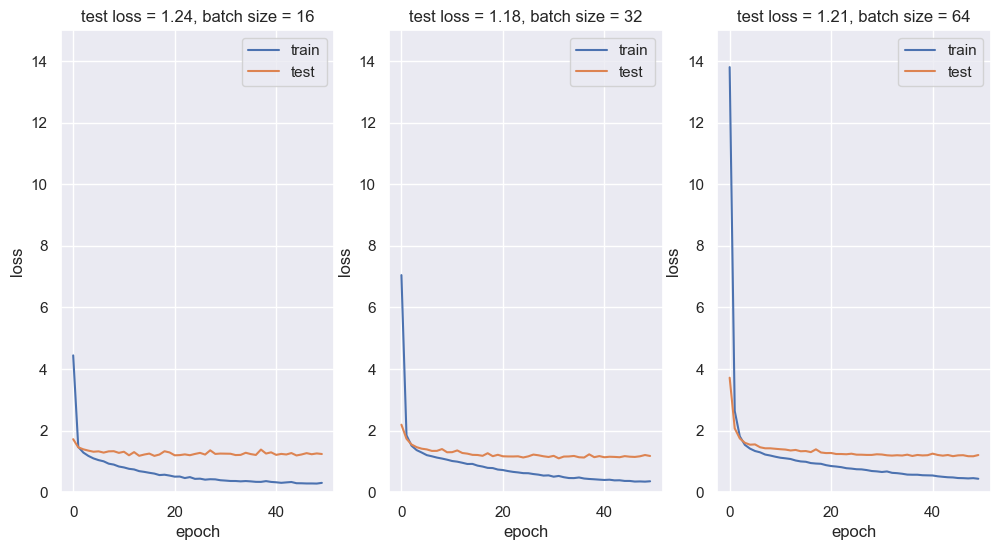

In [13]:
# 绘图
fig = plt.figure(figsize=(12, 6))
sns.set(color_codes=True)
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

        # 在 x_train, y_train 数据上拟合模型
    history = model.fit(
        np.array(list((x_train))).astype(float),
        y_train.values,
        batch_size=batch,
        validation_data=(np.array(list((x_test))).astype(float), y_test.values),
        verbose=0,
        epochs=nb_epoch,
    )
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.ylim((0, 15))
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
plt.show()

从上面的损失图中可以看出，batch size 为 16 似乎能给出最佳性能。

[_ModelCheckpoint callback_](https://keras.io/api/callbacks/) 用于以一定间隔将最佳模型/权重保存（在 checkpoint 文件中），以便模型/权重可以原样保存，或稍后加载以从保存的状态继续训练。

现在，我们使用 batch size 为 16 训练模型（因为从上图可以看出，它具有最低的测试损失），并将提供最佳性能的权重保存到文件 `best_weights.hdf5` 中。

In [20]:
# 保存训练好的模型
filepath = DATA / "best_weights.weights.h5"
checkpoint = ModelCheckpoint(
    str(filepath),
    monitor="loss",
    verbose=0,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# 拟合模型
model.fit(
    np.array(list((x_train))).astype(float),
    y_train.values,
    epochs=nb_epoch,
    batch_size=16,
    callbacks=callbacks_list,
    verbose=0,
)

### 评估与在测试集上的预测

[evaluate()](https://keras.io/api/models/model_training_apis/#evaluate-method) 方法用于检查模型的性能。它报告 **损失**（在我们的例子中是 MSE）以及评估指标（**mse** 和 **mae**）。

In [21]:
# 评估模型
print(f"在测试数据上评估模型")
scores = model.evaluate(np.array(list((x_test))), y_test.values, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse（与 loss 相同）: {scores[1]:.2f}")
print(f" mae: {scores[2]:.2f}")

Evaluate the model on the test data
 loss: 1.23
 mse (same as loss): 1.23
 mae: 0.84


测试集上的平均绝对误差低于 $1.0$，考虑到 pIC50 值的范围，这相当低。

我们现在预测测试数据上的 pIC50 值。 

In [22]:
# 预测 x_test 数据上的 pIC50 值
y_pred = model.predict(np.array(list((x_test))))

# 打印前 5 个 pIC50 预测值
first_5_prediction = [print(f"{value[0]:.2f}") for value in y_pred[0:5]]

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4.90
7.97
6.96
8.04
8.75


#### 散点图

为了可视化预测结果，我们绘制测试集上预测值与真实 pIC50 值的散点图。 

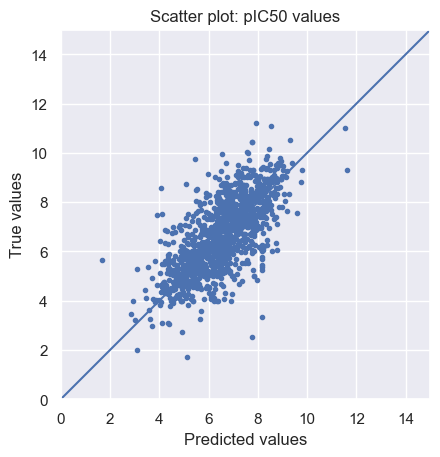

In [23]:
# 散点图
limits = 0, 15
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

正如我们所见，预测值与真实值之间存在正线性关系，但拟合远非完美。

### 在外部/未标注数据上的预测

我们使用训练好的神经网络来预测 `test.csv` 文件中未标注化合物的 pIC50 值。

In [24]:
# 加载外部/未标注数据集
external_data = pd.read_csv(DATA / "test.csv", index_col=0)
external_data = external_data.reset_index(drop=True)
external_data.head()
# NBVAL_CHECK_OUTPUT

,canonical_smiles
0,S(Cc1c([O-])c(OC)cc(/C=C(\C#N)/C(=O)N)c1)c1ccccc1
1,S=C(N)N1C(c2ccc(OC)cc2)CC(c2cc(C)c(C)cc2)=N1
2,Clc1c(O)cc(-c2nn(C(C)C)c3ncnc(N)c23)cc1
3,O=C(/C=C/CN1CC[NH+](C)CC1)N1Cc2sc3ncnc(N[C@H](...
4,S(=O)(=O)(NC(=O)Cn1c(C)ncc1[N+](=O)[O-])c1ccc(...


我们使用相同的 `smiles_to_fp` 函数，将 SMILES 字符串转换为 MACCS 指纹。

In [25]:
# 将 SMILES 字符串转换为 MACCS 指纹
external_data["fingerprints_df"] = external_data["canonical_smiles"].apply(smiles_to_fp)

# 查看前几行
    print("数据框的形状 : ", external_data.shape)
external_data.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe :  (60, 2)


,canonical_smiles,fingerprints_df
0,S(Cc1c([O-])c(OC)cc(/C=C(\C#N)/C(=O)N)c1)c1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,S=C(N)N1C(c2ccc(OC)cc2)CC(c2cc(C)c(C)cc2)=N1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Clc1c(O)cc(-c2nn(C(C)C)c3ncnc(N)c23)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


**注意**：为了结果的可重复性，我们在 `ANN_model.hdf5` 下保存了一个模型，其架构与上面相同。尽管模型相同，但由于 _随机_ 梯度算法中的随机性，每次运行保存的权重可能会有所差异。我们使用 [load_model()](https://keras.io/api/models/model_saving_apis/#loadmodel-function) 函数加载 ANN 模型权重。 

In [26]:
# 加载模型
model = load_model(DATA / "ANN_model.hdf5", compile=False)

In [27]:
# 在外部/未标注数据上的预测
predictions = model.predict(
    np.array(list((external_data["fingerprints_df"]))).astype(float), callbacks=callbacks_list
)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_pIC50_df = external_data.join(predicted_pIC50)

predicted_pIC50_df.head(3)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


,canonical_smiles,fingerprints_df,predicted_pIC50
0,S(Cc1c([O-])c(OC)cc(/C=C(\C#N)/C(=O)N)c1)c1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.779419
1,S=C(N)N1C(c2ccc(OC)cc2)CC(c2cc(C)c(C)cc2)=N1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.483406
2,Clc1c(O)cc(-c2nn(C(C)C)c3ncnc(N)c23)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.343009


In [28]:
# 将预测值保存为 data 文件夹中的 csv 文件
predicted_pIC50_df.to_csv(DATA / "predicted_pIC50_df.csv")

#### 选出前 3 个化合物

我们选出预测 pIC50 值最高的 3 个化合物，它们可以作为潜在的 EGFR 抑制剂进一步研究。

In [29]:
# 选出前 3 个化合物
predicted_pIC50_df = pd.read_csv(DATA / "predicted_pIC50_df.csv", index_col=0)
top3_drug = predicted_pIC50_df.nlargest(3, "predicted_pIC50")
top3_drug

,canonical_smiles,fingerprints_df,predicted_pIC50
9,Brc1cc(Nc2ncnc3nc(NC)ccc23)ccc1,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.481803
53,c1cc(ccc1Nc2c(c(nc[nH+]2)NCCCn3cc[nH+]c3)N)I,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.144416
18,Clc1c(F)ccc(NC=2N=CNC=3C=2C=C(OCCCCC=C=C)C(=O)...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.120270


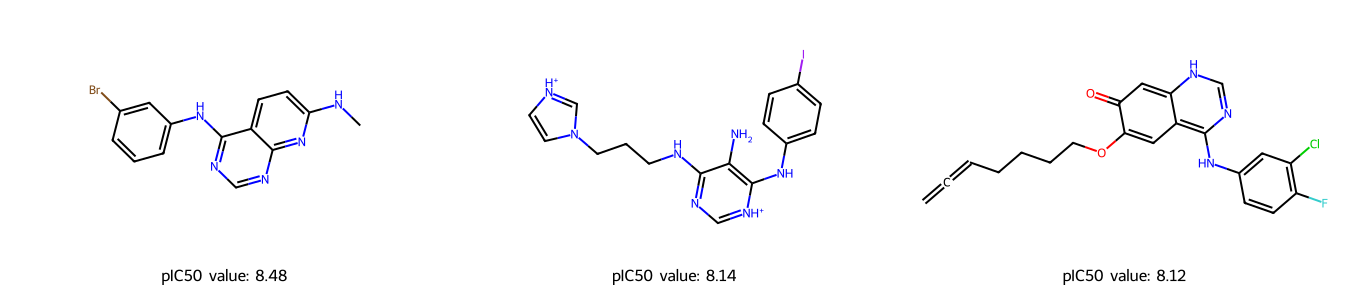

In [30]:
# 绘制化合物分子
highest_pIC50 = predicted_pIC50_df["canonical_smiles"][top3_drug.index]

mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [(f"pIC50 value: {value:.2f}") for value in pIC50_EGFR]

Draw.MolsToGridImage(mols_EGFR, molsPerRow=3, subImgSize=(450, 300), legends=pIC50_values)

## 讨论





从上面我们可以看到这三个分子之间存在一些相似性。例如，它们都含有苯胺和嘧啶基团，以及多个芳香碳环。

![化合物相似性](./images/drugs_similarity.png)

*图 5：* 表示选出的前三个化合物分子之间的相似性。

从上面我们可以看到这三个分子之间存在一些相似性。例如，它们都含有苯胺和嘧啶基团，以及多个芳香碳环。

![化合物相似性](./images/drugs_similarity.png)

*图 5：* 表示选出的前三个化合物分子之间的相似性。

由于外部/未标注数据同样来自 ChEMBL，我们可以再次确认我们的预测是否有意义。例如，第一个化合物，SMILES 为 `Brc1cc(Nc2ncnc3nc(NC)ccc23)ccc1`，预测 pIC50 值为 8.48，其对 EGFR 的实测亲和力较高：pIC50 值为 7.28，参见条目 [CHEMBL298637](https://www.ebi.ac.uk/chembl/compound_report_card/CHEMBL298637/)。

使用神经网络进行预测建模有一些优点：它不像实验室实验那样耗时，而且成本低得多。它还提示了可以作为潜在 EGFR 抑制剂进一步研究的分子的种类。

然而，这个模型也有一些缺点：它高度依赖于训练数据的化学空间、参数调整以及变量初始化，这些都可能会影响最终结果。
这样的模型既不提供关于化合物副作用的信息，也不提供其潜在毒性的信息。

## 测验

- 还有哪些其他超参数可以调整以获得更好的性能结果？
- 在定义模型时可以使用哪些其他激活函数和指标？
- 你能想到其他可视化方法来绘制预测值和观测值吗？

In [ ]:
-------
## 补充部分

<details>
    
<summary> 如果你对更多细节感兴趣，请继续阅读此部分。我们定义其他激活函数和前向传播函数，以更好地理解底层概念。 </summary>

**激活函数**

让我们讨论一些其他激活函数，并使用 Python 来定义它们。

1) **Sigmoid 函数 $\sigma$**：其形式为：$$\boxed{\sigma(x)=\frac{1}{1+e^{−x}}}.$$

   -  Sigmoid 曲线看起来像下图所示的 *S* 形曲线。
   - 它具有"平滑梯度"，可以防止输出值跳跃，并将输出值限制在 0 和 1 之间。
   - 建议仅在输出层上使用，以便输出可以解释为概率。
   - 如果你注意下图，对于 -2.5 到 2.5 之间的 $x$ 值，$y$ 值非常陡峭，因此该区域中 $x$ 值的任何小变化都会导致 $y$ 值显著变化。它倾向于将激活值带到曲线的两侧。
   - 然而，对于 $x$ 非常大或非常小的值，$y$ 值几乎没有变化，导致[**梯度消失**](https://towardsdatascience.com/the-vanishing-exploding-gradient-problem-in-deep-neural-networks-191358470c11)问题。这可能导致网络学习缓慢甚至拒绝进一步学习。

![sigmoid](images/sigmoid.png)

*图 6：* Sigmoid 函数的图示。图由 Sakshi Misra 绘制。


    

2) **双曲正切函数或 tanh**：其形式为：$$\boxed{f(x)= tanh(x) = \frac{e^x -  e^{-x}}{e^x + e^{-x}}}.$$

   - 它与 sigmoid 函数一样是非线性的，输出限制在 -1 和 1 之间。在 sigmoid 和 tanh 之间做出决定取决于当前的问题。
   - 与 sigmoid 类似，它也可能面临梯度消失问题。

![tanh](images/tanh.png)

*图 7：* 双曲正切 _tanh_ 函数的图示。图由 Sakshi Misra 绘制。
 

3) **Leaky Rectified Linear Unit**：其形式为：$$\boxed{f(x)= \max\{ α ∗ x,x\}}.$$

   - 这是 ReLU 的一个变体，在负区域有一个小的正斜率。
   - Leaky ReLU 的范围是 $(-\infty, \infty)$。
   - 它克服了 ReLU 的零梯度问题，并为 $x≤0$ 分配一个很小的 $\alpha$ 值。

![leaky](images/leaky.png)

*图 8：* "Leaky ReLU" 函数的图示。图由 Sakshi Misra 绘制。

我们应该选择哪种激活函数？

这主要取决于你试图解决的问题类型和计算成本。有很多激活函数，但总体思路保持不变。更多细节请参考 H. N. Mhaskar 的论文：[How to Choose an Activation Function](https://papers.nips.cc/paper/1993/file/51ef186e18dc00c2d31982567235c559-Paper.pdf)。

现在我们在 Python 中定义上面讨论的激活函数并绘制它们。


    
```python
# 定义可用于前向传播的激活函数
def sigmoid(input_array):
    """
    逐元素计算输入的 sigmoid 值。

    参数
    ----------
    input_array : array
             输入值。

    返回
    -------
    activation_function : array
             激活后的输出。
    input_array : array
             输入值。
    """
    activation_function = 1 / (1 + np.exp(-input_array))

    return activation_function, input_array


def tanh(x):
    """
    逐元素计算输入的双曲正切值。

    参数
    ----------
    input_array : array
             输入值。

    返回
    -------
    activation_function : array
             激活后的输出。
    input_array : array
             输入值。
    """
    activation_function = np.tanh(input_array)

    return activation_function, input_array


def relu(input_array):
    """
    逐元素计算整流线性单元 (ReLU) 值。

    参数
    ----------
    input_array : array
             输入值。
    返回
    -------
    activation_function : array
             激活后的输出。
    input_array : array
             输入值。
    """
    activation_function = np.maximum(0, input_array)

    return activation_function, input_array


def leaky_relu(input_array):
    """
    逐元素计算 Leaky Rectified Linear Unit 值。

    参数
    ----------
    input_array : array
             输入值。

    返回
    -------
    activation_function : array
             激活后的输出。
    input_array : array
             输入值。
    """
    activation_function = np.maximum(0.1 * input_array, input_array)

    return activation_function, input_array

```



我们也可以使用 `matplotlib` 库绘制所有激活函数，如下所示。



```python
# 绘制四种激活函数
input_array = np.linspace(-10, 10, 100)

# 计算激活后的输出
activation_sigmoid, input_array = sigmoid(input_array)
activation_tanh, input_array = tanh(input_array)
activation_relu, input_array = relu(input_array)
activation_leaky_relu, input_array = leaky_relu(input_array)

# 绘制 sigmoid 函数
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(input_array, activation_sigmoid, 'b')
plt.axvline(x=0, color='gray', linestyle='--')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("input(x)")
plt.ylabel(r"$\frac{1}{1 + e^{-x}}$")
plt.title("Sigmoid 函数", fontsize=16)

# 绘制 tanh 函数
plt.subplot(2, 2, 2)
plt.plot(input_array, activation_tanh, 'b')
plt.axvline(x=0, color='gray', linestyle='--')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("input(x)")
plt.ylabel(r"$\frac{e^x - e^{-x}}{e^x + e^{-x}}$")
plt.title("双曲正切函数", fontsize=16)

# 绘制 ReLU 函数
plt.subplot(2, 2, 3)
plt.plot(input_array, activation_relu, 'b')
plt.axvline(x=0, color='gray', linestyle='--')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("input(x)")
plt.ylabel(r"$max\{0, x\}$")
plt.title("ReLU 函数", fontsize=16)

# 绘制 Leaky ReLU 函数
plt.subplot(2, 2, 4)
plt.plot(input_array, activation_leaky_relu, 'b')
plt.axvline(x=0, color='gray', linestyle='--')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel("input(x)")
plt.ylabel(r"$max\{0.1x, x\}$")
plt.title("Leaky ReLU 函数", fontsize=16)
plt.tight_layout()
```

<br /> 

**前向传播**



现在，我们将使用类来定义前向传播函数，以更好地理解前向传播概念。

首先，我们定义一个名为 `Layer_Dense` 的类。它有两个属性：``weights`` 和 ``biases``。我们随机分配它们的值，并定义一个名为 `forward_pass` 的函数，该函数计算输入值和权重的 *点积* 并将其与偏置值相加。
由于我们知道激活函数应用于每个神经元，我们以 `ReLU` 为例创建另一个名为 `Activation_Function` 的类。

在定义类和它们的属性之后，我们从两个类创建对象并在我们的数据集上调用函数。然后我们可以打印输出值，即预测的 pIC50 值。

**注意：** 由于权重是随机分配的，每次运行预测值都会不同。



```python
# 创建一个带有单个隐藏层的前向传播函数
class Layer_Dense:
    """
    一个表示神经网络的类
    
    '''
    属性
    ----------
    n_inputs : int
        输入层中的神经元数量
    n_neurons : int
        隐藏层中的神经元数量

    方法
    ------
    forward_pass(inputs):
        计算神经网络的前向传播。
    """

    def __init__(self, n_inputs, n_neurons):
        """
        构造所有必要的属性。

        参数
        ----------
        n_inputs : int
            输入层中的神经元数量
        n_neurons : int
            隐藏层中的神经元数量

        """
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
        
    def forward_pass(self, inputs):
        """
        计算前向传播。

        参数
        ----------
        input : int
            输入神经元。

        返回
        -------
        None
        
        """
        self.output = np.dot(inputs, self.weights) + self.biases


class Activation_Function:
    """
    一个表示激活函数的类

    方法
    ------
    ReLU(inputs):
        应用 ReLU 激活函数。
    """
    def ReLU(self, inputs):
        """
        将激活函数应用于神经元。

        参数
        ----------
        input : int
            输入神经元。

        返回
        -------
        None
        
        """
        self.output = np.maximum(0, inputs)

     
# 对象
layer1 = Layer_Dense(167, 50)
layer2 = Layer_Dense(50, 1)
activation1 = Activation_Function()
activation2 = Activation_Function()

# 函数调用
layer1.forward_pass(np.array(list((chembl_df['fingerprints_df']))))
layer2.forward_pass(layer1.output)
activation1.ReLU(layer1.output)
activation2.ReLU(layer2.output)

print(activation2.output)
```


</details>